# Entraînement RandomForest v2

**Dataset :** triage_dataset_v2.pkl
**Features :** 18 dimensions (8 constantes + 10 symptômes binaires)
**Classes :** ROUGE / JAUNE / VERT / GRIS

## Imports

In [1]:
import pickle
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from collections import Counter
from pathlib import Path

from sklearn.model_selection import train_test_split, cross_val_score, StratifiedKFold
from sklearn.ensemble import RandomForestClassifier
from sklearn.preprocessing import StandardScaler
from sklearn.pipeline import Pipeline
from sklearn.metrics import (
    classification_report,
    confusion_matrix,
    accuracy_score,
    f1_score,
)
import joblib

print('Imports OK')

Imports OK


## Chargement du dataset

In [2]:
data_path = Path('../data/models/triage_dataset_v2.pkl')

with open(data_path, 'rb') as f:
    data = pickle.load(f)

X = data['X']
y = data['y']
feature_names = data['feature_names']
metadata = data['metadata']

print(f'Dataset chargé : {data_path.name}')
print(f'  X shape : {X.shape}')
print(f'  y shape : {y.shape}')
print(f'  Features : {feature_names}')
print()

counts = Counter(y)
print('Distribution des classes :')
for label in ['ROUGE', 'JAUNE', 'VERT', 'GRIS']:
    n = counts.get(label, 0)
    print(f'  {label:<6} : {n:3d} ({n/len(y)*100:.1f}%)')

Dataset chargé : triage_dataset_v2.pkl
  X shape : (129, 18)
  y shape : (129,)
  Features : ['FC', 'FR', 'SpO2', 'TA_sys', 'TA_dia', 'Temp', 'Age', 'Sexe', 'douleur thoracique', 'dyspnée', 'perte de connaissance', 'hémorragie', 'fracture', 'fièvre élevée', 'douleur abdominale', 'nausée vomissement', 'symptôme mineur', 'pas urgence']

Distribution des classes :
  ROUGE  :  33 (25.6%)
  JAUNE  :  31 (24.0%)
  VERT   :  31 (24.0%)
  GRIS   :  34 (26.4%)


## Exploration des features

In [3]:
df = pd.DataFrame(X, columns=feature_names)
df['label'] = y

print('Statistiques des constantes vitales :')
print(df[feature_names[:8]].describe().round(1))
print()

print('Fréquence des symptômes binaires :')
for f in feature_names[8:]:
    pct = df[f].mean() * 100
    bar = '█' * int(pct / 5)
    print(f'  {f:<30} : {pct:5.1f}% {bar}')

Statistiques des constantes vitales :
          FC     FR   SpO2  TA_sys  TA_dia   Temp    Age   Sexe
count  129.0  129.0  129.0   129.0   129.0  129.0  129.0  129.0
mean    98.8   20.7   95.0   119.5    76.7   37.5   44.0    0.5
std     14.0    4.0    3.7    20.8    12.0    0.8   13.8    0.5
min     75.0   16.0   88.0    85.0    50.0   36.8   22.0    0.0
25%     85.0   18.0   90.0   110.0    70.0   36.8   32.0    0.0
50%     95.0   20.0   97.0   120.0    78.0   37.2   45.0    0.0
75%    110.0   22.0   98.0   130.0    85.0   37.8   55.0    1.0
max    125.0   30.0   98.0   180.0   110.0   39.5   72.0    1.0

Fréquence des symptômes binaires :
  douleur thoracique             :   7.0% █
  dyspnée                        :  20.2% ████
  perte de connaissance          :   0.8% 
  hémorragie                     :  13.2% ██
  fracture                       :  39.5% ███████
  fièvre élevée                  :  15.5% ███
  douleur abdominale             :  73.6% ██████████████
  nausée vomisseme

## Split Train / Test

In [4]:
X_train, X_test, y_train, y_test = train_test_split(
    X, y,
    test_size=0.2,
    random_state=42,
    stratify=y,
)

print(f'Train : {len(X_train)} cas  |  Test : {len(X_test)} cas')
print()
print('Distribution train :', Counter(y_train))
print('Distribution test  :', Counter(y_test))

Train : 103 cas  |  Test : 26 cas

Distribution train : Counter({np.str_('GRIS'): 27, np.str_('ROUGE'): 26, np.str_('VERT'): 25, np.str_('JAUNE'): 25})
Distribution test  : Counter({np.str_('ROUGE'): 7, np.str_('GRIS'): 7, np.str_('JAUNE'): 6, np.str_('VERT'): 6})


## Entraînement

In [5]:
# Pipeline : normalisation des constantes + RandomForest
clf = Pipeline([
    ('scaler', StandardScaler()),
    ('rf', RandomForestClassifier(
        n_estimators=200,
        max_depth=None,
        min_samples_split=2,
        min_samples_leaf=1,
        class_weight='balanced',
        random_state=42,
        n_jobs=-1,
    )),
])

clf.fit(X_train, y_train)
print('Modèle entraîné !')

Modèle entraîné !


## Métriques sur le test set

In [6]:
y_pred = clf.predict(X_test)

accuracy = accuracy_score(y_test, y_pred)
f1 = f1_score(y_test, y_pred, average='weighted')
f1_macro = f1_score(y_test, y_pred, average='macro')

print(f'PERFORMANCES TEST SET')
print(f'  Accuracy       : {accuracy*100:.1f}%')
print(f'  F1 weighted    : {f1:.3f}')
print(f'  F1 macro       : {f1_macro:.3f}')
print()
print(classification_report(y_test, y_pred, target_names=['GRIS', 'JAUNE', 'ROUGE', 'VERT'], zero_division=0))

PERFORMANCES TEST SET
  Accuracy       : 73.1%
  F1 weighted    : 0.722
  F1 macro       : 0.718

              precision    recall  f1-score   support

        GRIS       0.56      0.71      0.62         7
       JAUNE       0.86      1.00      0.92         6
       ROUGE       1.00      0.86      0.92         7
        VERT       0.50      0.33      0.40         6

    accuracy                           0.73        26
   macro avg       0.73      0.73      0.72        26
weighted avg       0.73      0.73      0.72        26



## Matrice de confusion

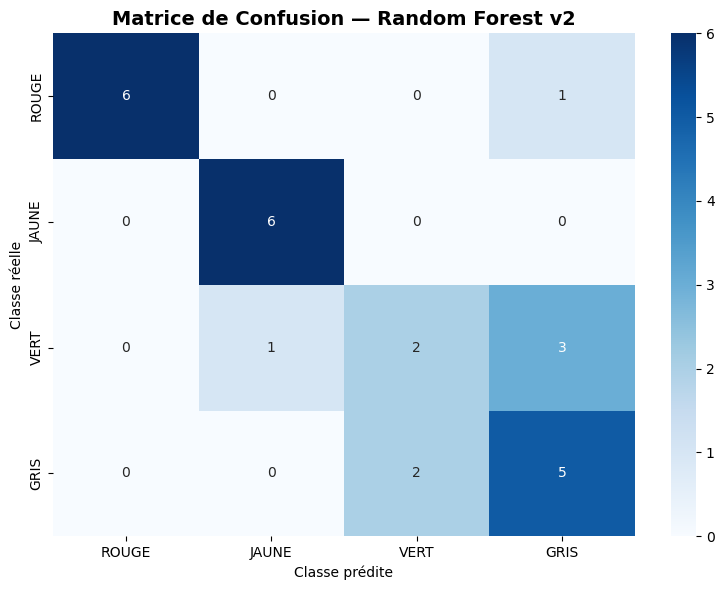

In [7]:
labels = ['ROUGE', 'JAUNE', 'VERT', 'GRIS']
cm = confusion_matrix(y_test, y_pred, labels=labels)

plt.figure(figsize=(8, 6))
sns.heatmap(
    cm, annot=True, fmt='d', cmap='Blues',
    xticklabels=labels, yticklabels=labels,
)
plt.title('Matrice de Confusion — Random Forest v2', fontsize=14, fontweight='bold')
plt.ylabel('Classe réelle')
plt.xlabel('Classe prédite')
plt.tight_layout()
plt.show()

## Validation croisée (5-fold)

In [8]:
cv = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)
cv_scores = cross_val_score(clf, X, y, cv=cv, scoring='accuracy')
cv_f1 = cross_val_score(clf, X, y, cv=cv, scoring='f1_weighted')

print('VALIDATION CROISÉE 5-fold')
print(f'  Accuracy : {cv_scores.mean()*100:.1f}% (± {cv_scores.std()*100:.1f}%)')
print(f'  F1 weighted : {cv_f1.mean():.3f} (± {cv_f1.std():.3f})')
print()
for i, (acc, f1) in enumerate(zip(cv_scores, cv_f1), 1):
    print(f'  Fold {i} : acc={acc*100:.1f}%  f1={f1:.3f}')

VALIDATION CROISÉE 5-fold
  Accuracy : 83.8% (± 8.8%)
  F1 weighted : 0.832 (± 0.091)

  Fold 1 : acc=76.9%  f1=0.762
  Fold 2 : acc=80.8%  f1=0.801
  Fold 3 : acc=96.2%  f1=0.962
  Fold 4 : acc=73.1%  f1=0.723
  Fold 5 : acc=92.0%  f1=0.915


## Importance des features

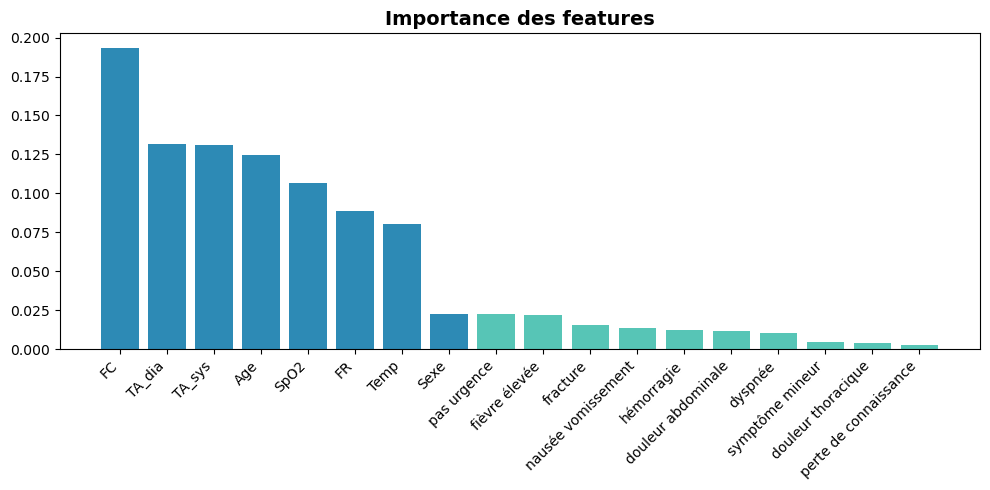

Ranking :
   1. FC                             : 0.1931
   2. TA_dia                         : 0.1314
   3. TA_sys                         : 0.1309
   4. Age                            : 0.1247
   5. SpO2                           : 0.1069
   6. FR                             : 0.0887
   7. Temp                           : 0.0807
   8. Sexe                           : 0.0228
   9. pas urgence                    : 0.0226
  10. fièvre élevée                  : 0.0220
  11. fracture                       : 0.0155
  12. nausée vomissement             : 0.0139
  13. hémorragie                     : 0.0124
  14. douleur abdominale             : 0.0120
  15. dyspnée                        : 0.0107
  16. symptôme mineur                : 0.0044
  17. douleur thoracique             : 0.0043
  18. perte de connaissance          : 0.0030


In [9]:
importances = clf.named_steps['rf'].feature_importances_
indices = np.argsort(importances)[::-1]

plt.figure(figsize=(10, 5))
colors = ['#2d8ab5' if i < 8 else '#57c5b6' for i in indices]
plt.bar(range(len(importances)), importances[indices], color=colors)
plt.xticks(range(len(importances)), [feature_names[i] for i in indices], rotation=45, ha='right')
plt.title('Importance des features', fontsize=14, fontweight='bold')
plt.tight_layout()
plt.show()

print('Ranking :')
for rank, i in enumerate(indices, 1):
    print(f'  {rank:2d}. {feature_names[i]:<30} : {importances[i]:.4f}')

## Sauvegarde du modèle

In [10]:
model_path = Path('../data/models/random_forest_v2.pkl')
joblib.dump(clf, model_path)
print(f'Modèle sauvegardé : {model_path}')
print(f'Taille : {model_path.stat().st_size / 1024:.1f} KB')

Modèle sauvegardé : ..\data\models\random_forest_v2.pkl
Taille : 1186.1 KB
